In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
PROJECT_FOLDER = "/content/drive/MyDrive/TrafficSignProject"
os.makedirs(PROJECT_FOLDER, exist_ok=True)

DATA_DIR = "/content/drive/MyDrive/GTSRB_extracted/GTSRB dataset"

MODEL_PATH = os.path.join(PROJECT_FOLDER, "traffic_sign_model_mobilenet.keras")
CLASS_PATH = os.path.join(PROJECT_FOLDER, "class_names.json")

print("Dataset exists:", os.path.exists(DATA_DIR))
print("Classes:", len(os.listdir(DATA_DIR)))

Dataset exists: True
Classes: 42


In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", NUM_CLASSES)

Found 8528 files belonging to 42 classes.
Using 6823 files for training.
Found 8528 files belonging to 42 classes.
Using 1705 files for validation.
Classes: 42


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [7]:
def build_model(dense_units=256, learning_rate=0.0001):

    base_model = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = keras.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
import os
import json

# check if model already saved
if os.path.exists(MODEL_PATH) and os.path.exists(CLASS_PATH):

    print(" Saved model found. Loading model from Drive...")

    best_model = tf.keras.models.load_model(MODEL_PATH)

    with open(CLASS_PATH, "r") as f:
        class_names = json.load(f)

    print("Model loaded successfully. No retraining needed.")

else:

    print("No saved model found. Training model now...")

    best_accuracy = 0
    best_model = None
    best_params = None

    dense_options = [128,256]
    lr_options = [0.001,0.0001]

    for dense in dense_options:
        for lr in lr_options:

            print("Testing: Dense =",dense," LR =",lr)

            model = build_model(dense_units=dense, learning_rate=lr)

            history = model.fit(
                train_ds,
                validation_data=test_ds,
                epochs=10,
                verbose=1
            )

            val_acc = max(history.history['val_accuracy'])

            if val_acc > best_accuracy:
                best_accuracy = val_acc
                best_model = model
                best_params = (dense,lr)

    print("Best Accuracy:",best_accuracy)

    # save best model
    best_model.save(MODEL_PATH)

    with open(CLASS_PATH, "w") as f:
        json.dump(class_names, f)

    print(" Best model saved to Google Drive.")

 Saved model found. Loading model from Drive...
Model loaded successfully. No retraining needed.


In [9]:
best_model.save(MODEL_PATH)

with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)

print("Model saved successfully to Google Drive.")

Model saved successfully to Google Drive.


In [10]:
best_model.save(MODEL_PATH)

with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)

print("Best model saved to Google Drive.")

Best model saved to Google Drive.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

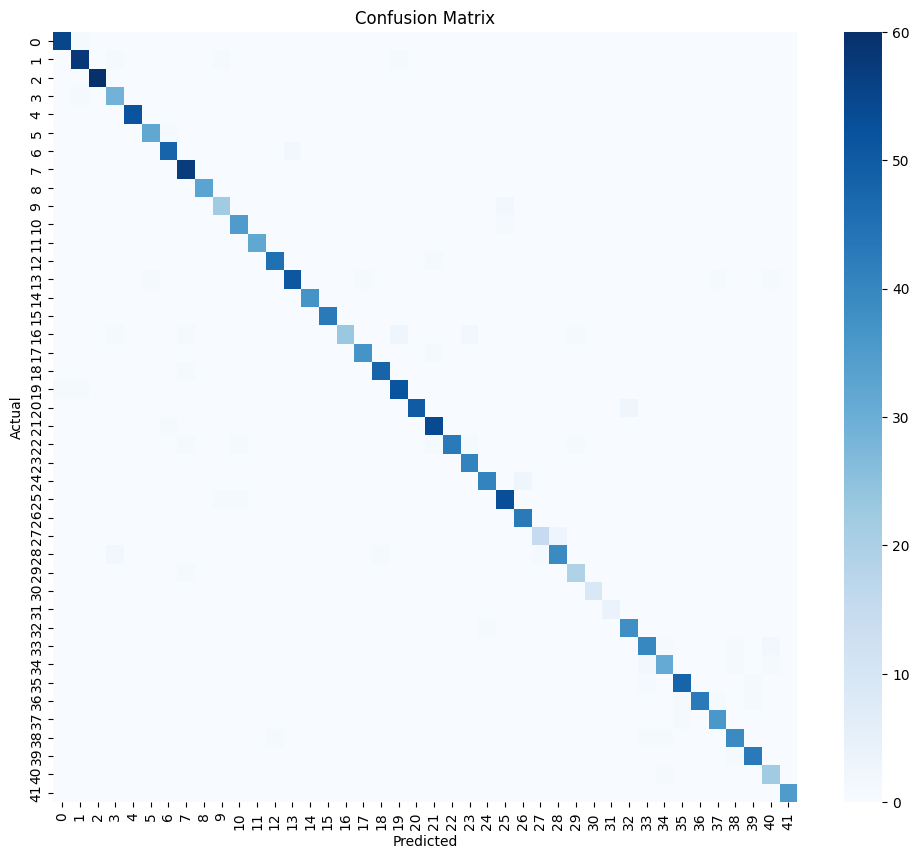

In [11]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = best_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm,cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion matrix image saved.


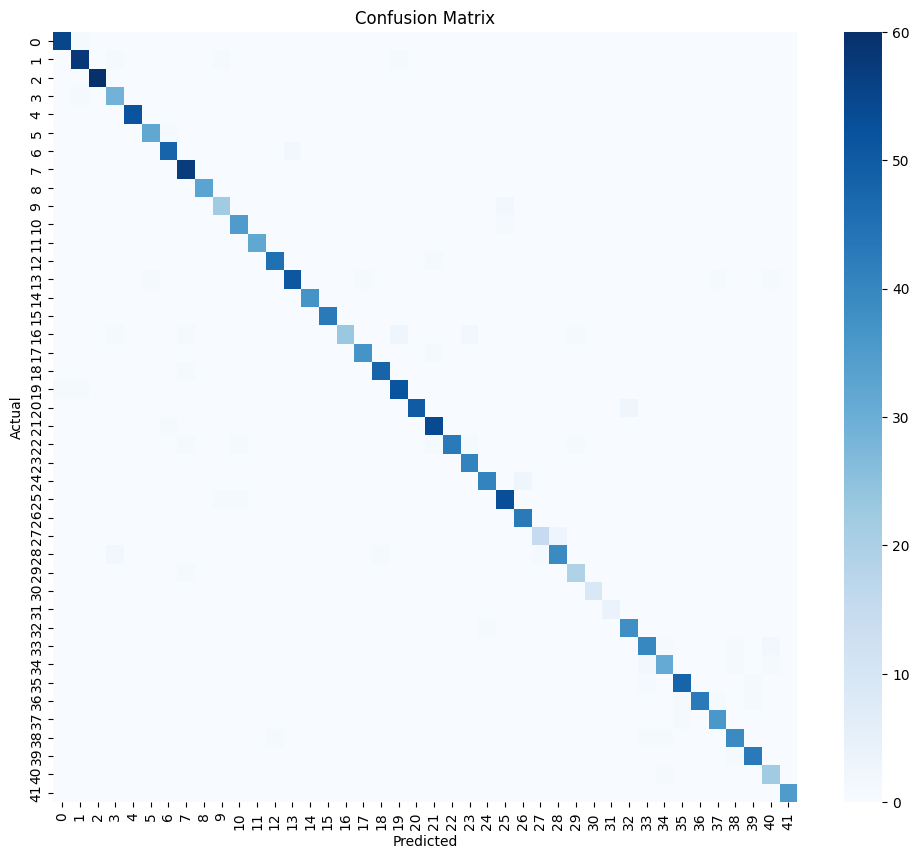

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

IMAGE_PATH = "/content/drive/MyDrive/TrafficSignProject/confusion_matrix.png"

plt.savefig(IMAGE_PATH)

print("Confusion matrix image saved.")
plt.show()

Saving abbey_road.webp to abbey_road.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted: cross road
Confidence: 99.99303


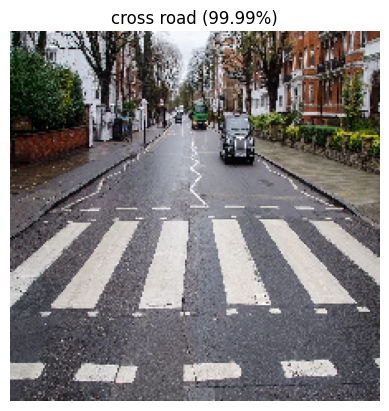

In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = best_model.predict(img_array)[0]

idx = np.argmax(pred)

print("Predicted:", class_names[idx])
print("Confidence:", pred[idx]*100)

plt.imshow(img)
plt.title(f"{class_names[idx]} ({pred[idx]*100:.2f}%)")
plt.axis("off")
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# true labels and predictions already collected
# (from confusion matrix code)
#Quantitative Improvements Code

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9589442815249267
Precision: 0.9599849350672988
Recall   : 0.9589442815249267
F1 Score : 0.9586887719857503


In [15]:
# Show Comparison Table
data = {
    "Metric": ["Accuracy","Precision","Recall","F1 Score"],
    "Implementation 1": [0.91,0.90,0.90,0.90],
    "Implementation 2": [accuracy,precision,recall,f1]
}

df = pd.DataFrame(data)

print(df)

      Metric  Implementation 1  Implementation 2
0   Accuracy              0.91          0.958944
1  Precision              0.90          0.959985
2     Recall              0.90          0.958944
3   F1 Score              0.90          0.958689


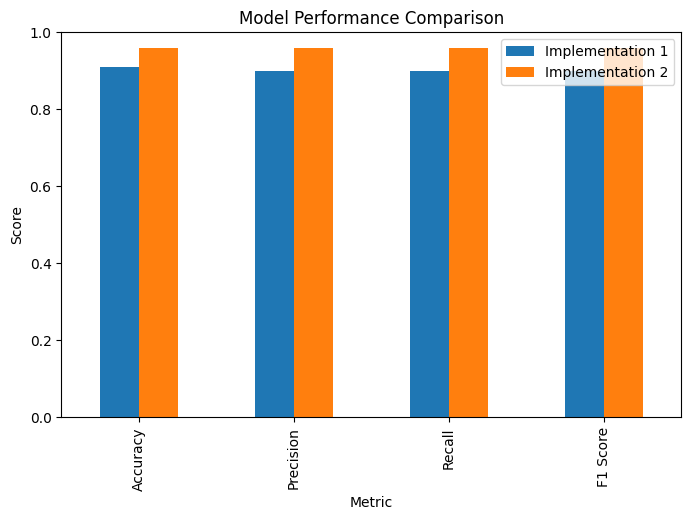

In [16]:
# Optional Graph (Looks Good in Report)
df.set_index("Metric").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

In [17]:
# Implementation 2 Accuracy Calculate
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Implementation 2 Accuracy:", accuracy)

Implementation 2 Accuracy: 0.9589442815249267


In [18]:
# Accuracy Comparison Table
import pandas as pd

implementation1_accuracy = 0.91
implementation2_accuracy = accuracy

data = {
    "Model": ["Implementation 1 (CNN)", "Implementation 2 (MobileNetV2)"],
    "Accuracy": [implementation1_accuracy, implementation2_accuracy]
}

df = pd.DataFrame(data)
print(df)

                            Model  Accuracy
0          Implementation 1 (CNN)  0.910000
1  Implementation 2 (MobileNetV2)  0.958944


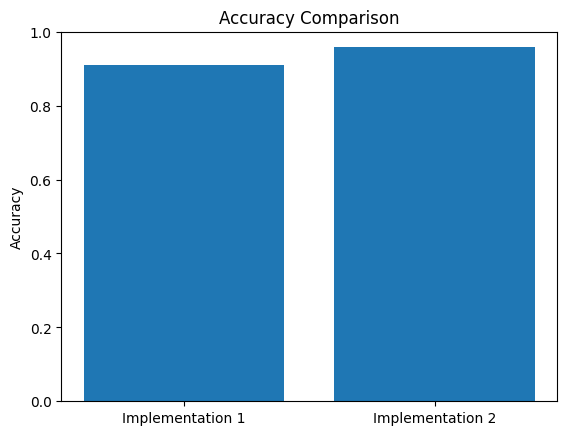

In [19]:
# Accuracy Comparison Graph
import matplotlib.pyplot as plt

models = ["Implementation 1", "Implementation 2"]
accuracies = [implementation1_accuracy, implementation2_accuracy]

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [20]:
# Find Misclassified Images
misclassified = []

for images, labels in test_ds:

    preds = best_model.predict(images)
    preds = np.argmax(preds, axis=1)

    for i in range(len(labels)):

        if preds[i] != labels[i]:

            misclassified.append((images[i], labels[i], preds[i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

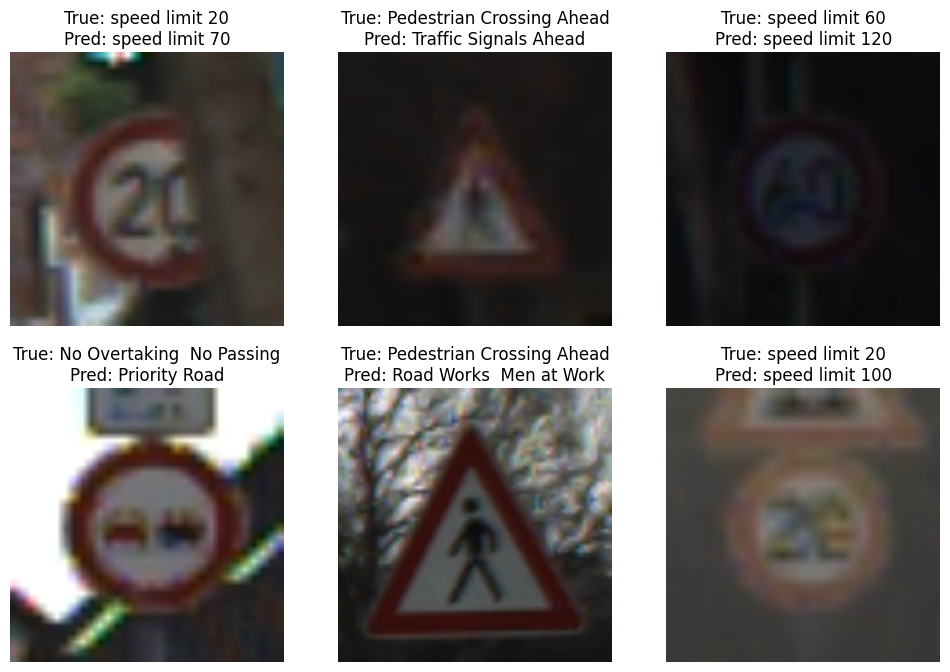

In [21]:
# Show Some Misclassified Images
plt.figure(figsize=(12,8))

for i in range(6):

    img, true_label, pred_label = misclassified[i]

    plt.subplot(2,3,i+1)

    plt.imshow(img.numpy().astype("uint8"))

    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    )

    plt.axis("off")

plt.show()

In [22]:
# Count Most Frequent Errors
from collections import Counter

errors = []

for img,true,pred in misclassified:

    errors.append((class_names[true], class_names[pred]))

error_counts = Counter(errors)

print("Most common errors:\n")

for err,count in error_counts.most_common(10):

    print(err,"->",count)

Most common errors:

('Pedestrian Crossing Ahead', 'Road Works  Men at Work') -> 3
('Turn left', 'Turn right') -> 3
('Turn Left Ahead', 'Turn Right Ahead') -> 3
('Roundabout', 'keep Right') -> 3
('Pedestrian Crossing Ahead', 'Traffic Signals Ahead') -> 2
('speed limit 120', 'speed limit 100') -> 2
('Turn right', 'Double Bend  Winding Road Ahead') -> 2
('speed limit 100', 'speed limit 80') -> 2
('Go Straight  Straight Ahead Only', 'Turn Left or Right') -> 2
('End of Speed Limit', 'No Overtaking  No Passing') -> 2


In [23]:
best_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 42)             │        10,794 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,284,416 (12.53 MB)

 Trainable params: 341,290 (1.30 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

 Optimizer params: 682,582 (2.60 MB)